# Factors That Help Formula One Drivers Improve Race Performance

Student IDs:
- 2791579 (Yanqi Li)
- Student 2 ID
- Student 3 ID

## 1. Introduction

Formula One is a highly competitive motorsport where a driver's final race performance is influenced by many different factors. A driver’s finishing position is not only determined by driving skill, but also by starting grid position, pit stop speed, constructor performance, and race strategy. In this project, we are interested in the question: “**What factors help Formula One drivers improve their race performance?**” We define improvement mainly through positions gained, which compares where a driver started the race to where they finished. This question is important because it helps us understand whether success in Formula One comes more from the driver’s starting position, race execution, pit stop efficiency, or team support.

To answer this question, we use multiple Formula One datasets, including race results, pit stops, qualifying results, races, drivers, and constructors. We first merge these datasets together, then create key variables such as driver name, positions gained, podium finish, top-ten finish, average pit stop time, and number of pit stops. Our analysis uses summary tables and visualizations to compare starting grid position, pit stop performance, constructors, and year trends. Overall, our results suggest that starting grid position is one of the strongest factors related to race performance: drivers who start near the front tend to score more points, while drivers starting farther back may gain more positions but still finish with fewer points. Pit stop speed has a weaker relationship with positions gained than expected, while constructor strength also appears to matter because teams differ in engineering, strategy, and overall race execution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Description
This project uses six Formula One datasets: results, pit stops, qualifying, races, drivers, and constructors. The results table contains one row for each driver's result in a race. The pit stops table records pit stop information for drivers during races. The qualifying table gives qualifying positions for drivers, while the races table provides race-level information such as year and race name. The drivers table contains driver-level information, and the constructors table contains team-level information.

### Read all files that we need

In [2]:
results = pd.read_csv("1-Formula_One/results.csv")
pit_stops = pd.read_csv("1-Formula_One/pit_stops.csv")
qualifying = pd.read_csv("1-Formula_One/qualifying.csv")
races = pd.read_csv("1-Formula_One/races.csv")
drivers = pd.read_csv("1-Formula_One/drivers.csv")
constructors = pd.read_csv("1-Formula_One/constructors.csv")

### Dataset Shape Table

The table below shows the number of rows and columns in each dataset used in this project.

In [3]:
dataset_shape = pd.DataFrame({
    "Dataset": ["results", "pit_stops", "qualifying", "races", "drivers", "constructors"],
    "Rows": [
        results.shape[0],
        pit_stops.shape[0],
        qualifying.shape[0],
        races.shape[0],
        drivers.shape[0],
        constructors.shape[0]
    ],
    "Columns": [
        results.shape[1],
        pit_stops.shape[1],
        qualifying.shape[1],
        races.shape[1],
        drivers.shape[1],
        constructors.shape[1]
    ]
})

dataset_shape

,Dataset,Rows,Columns
0,results,25660,18
1,pit_stops,9299,7
2,qualifying,9395,9
3,races,1079,18
4,drivers,854,9
5,constructors,211,5


### Clean and summarize pit stop data

In [4]:
# Convert pit stop time from milliseconds to seconds
pit_stops["pit_seconds"] = pit_stops["milliseconds"] / 1000

# Group by raceId and driverId so that each row represents one driver in one race
pit_summary = pit_stops.groupby(["raceId", "driverId"]).agg(
    avg_pit_seconds=("pit_seconds", "mean"),
    total_pit_seconds=("pit_seconds", "sum"),
    num_pit_stops=("pit_seconds", "count")
)

# Reset the index so raceId and driverId become regular columns again
pit_summary = pit_summary.reset_index()

pit_summary.head()

,raceId,driverId,avg_pit_seconds,total_pit_seconds,num_pit_stops
0,841,1,23.213,46.426,2
1,841,2,24.046,48.092,2
2,841,3,23.716,23.716,1
3,841,4,24.055,72.165,3
4,841,5,24.865,24.865,1


### Clean qualifying data

In [5]:
# Keep only the columns we need from the qualifying dataset
qualifying_clean = qualifying[["raceId", "driverId", "position"]]

# Rename the position column so it clearly means qualifying position
qualifying_clean = qualifying_clean.rename(
    columns={"position": "qualifying_position"}
)

qualifying_clean.head()

,raceId,driverId,qualifying_position
0,18,1,1
1,18,9,2
2,18,5,3
3,18,13,4
4,18,2,5


## 3. Merging Procedure

We use `results` as the main table because each row represents one driver’s result in one race. We first merge the pit stop summary into the main dataset using `raceId` and `driverId`, because pit stop performance is measured for each driver in each race. Then we merge qualifying data using the same two keys. Finally, we merge race, driver, and constructor information using `raceId`, `driverId`, and `constructorId`.

In [6]:
f1_merged = results

# Merge pit stop summary into the main dataset
f1_merged = f1_merged.merge(
    pit_summary,
    on=["raceId", "driverId"],
    how="left"
)

# We merge by raceId and driverId because qualifying position is also for each driver in each race
f1_merged = f1_merged.merge(
    qualifying_clean,
    on=["raceId", "driverId"],
    how="left"
)


# raceId connects each result to race-level information such as year, round, and race name
f1_merged = f1_merged.merge(
    races,
    on="raceId",
    how="left"
)


# driverId connects each result to driver-level information such as driver name and nationality
f1_merged = f1_merged.merge(
    drivers,
    on="driverId",
    how="left"
)


# constructorId connects each result to team-level information
f1_merged = f1_merged.merge(
    constructors,
    on="constructorId",
    how="left"
)

f1_merged.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_y,constructorRef,name_y,nationality_y,url
0,1,18,1,1,22,1,1,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,18,4,4,5,11,4,4,4,5.0,...,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,18,5,1,23,3,5,5,5,4.0,...,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren


## 4. Data Cleaning and Variable Creation

After merging the datasets, we created several key variables for analysis. We converted pit stop time from milliseconds to seconds and summarized pit stop performance at the race-driver level. We also created `driver_name`, `positions_gained`, `podium`, and `finished_top_10`. Finally, we removed rows with invalid starting grid positions because those rows cannot be used to measure position improvement.

In [7]:
f1_merged["driver_name"] = f1_merged["forename"] + " " + f1_merged["surname"]

# Calculate how many positions the driver gained during the race
f1_merged["positions_gained"] = f1_merged["grid"] - f1_merged["positionOrder"]

# Create a podium variable
# If positionOrder is 1, 2, or 3, then the driver got a podium finish
f1_merged["podium"] = f1_merged["positionOrder"] <= 3

# Create a finished_top_10 variable
# If positionOrder is 10 or lower, then the driver finished in the top 10
f1_merged["finished_top_10"] = f1_merged["positionOrder"] <= 10

f1_merged[[
    "driver_name",
    "grid",
    "positionOrder",
    "positions_gained",
    "podium",
    "finished_top_10"
]].head()

,driver_name,grid,positionOrder,positions_gained,podium,finished_top_10
0,Lewis Hamilton,1,1,0,True,True
1,Nick Heidfeld,5,2,3,True,True
2,Nico Rosberg,7,3,4,True,True
3,Fernando Alonso,11,4,7,False,True
4,Heikki Kovalainen,3,5,-2,False,True


In [8]:
# Keep only rows where the driver had a valid starting grid position
f1_clean = f1_merged[f1_merged["grid"] > 0]

# Keep only rows where positionOrder is not missing
f1_clean = f1_clean[f1_clean["positionOrder"].notna()]

f1_clean.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,nationality_x,url_y,constructorRef,name_y,nationality_y,url,driver_name,positions_gained,podium,finished_top_10
0,1,18,1,1,22,1,1,1,1,10.0,...,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Lewis Hamilton,0,True,True
1,2,18,2,2,3,5,2,2,2,8.0,...,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,Nick Heidfeld,3,True,True
2,3,18,3,3,7,7,3,3,3,6.0,...,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,Nico Rosberg,4,True,True
3,4,18,4,4,5,11,4,4,4,5.0,...,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,Fernando Alonso,7,False,True
4,5,18,5,1,23,3,5,5,5,4.0,...,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Heikki Kovalainen,-2,False,True


## 5. Results

### 5.1. Position Gain Analysis

In F1 racing, position gain measures how much a driver moved up or down in the final standings relative to where they started. It is calculated as starting grid position minus finishing position, so a positive number means the driver gained places during the race, and a negative number means they dropped back. This section looks at how position gain is distributed across all races, and whether a driver's starting grid position has a consistent effect on how much they can gain.

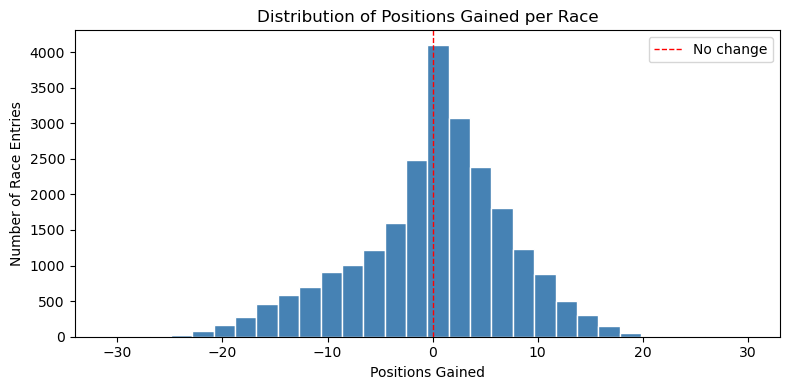

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(f1_clean['positions_gained'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No change')
ax.set_title('Distribution of Positions Gained per Race')
ax.set_xlabel('Positions Gained')
ax.set_ylabel('Number of Race Entries')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
f1_clean['positions_gained'].describe().round(2).to_frame()

,positions_gained
count,24056.00
mean,0.01
std,7.27
min,-31.00
25%,-4.00
50%,1.00
75%,5.00
max,30.00


The distribution is centered close to zero, which means most drivers finish near where they started. The red dashed line marks zero — values to the right represent position gains and values to the left represent losses. The spread is wider on the positive side, suggesting that while large gains are possible, the most extreme swings tend to be upward rather than downward.

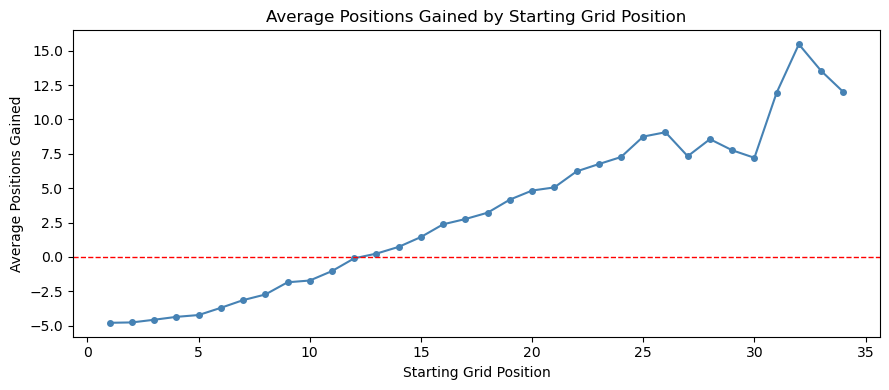

In [11]:
grid_pg = (f1_clean
           .groupby('grid')['positions_gained']
           .mean()
           .reset_index())
grid_pg.columns = ['grid', 'avg_positions_gained']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grid_pg['grid'], grid_pg['avg_positions_gained'], marker='o', color='steelblue', markersize=4)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Average Positions Gained by Starting Grid Position')
ax.set_xlabel('Starting Grid Position')
ax.set_ylabel('Average Positions Gained')
plt.tight_layout()
plt.show()

There is a clear downward trend as grid position increases. Drivers starting near the back gain the most positions on average, while drivers starting at the front often end up with near-zero or negative position gain. This pattern reflects a structural ceiling: a driver starting first can only maintain or lose their position, while a driver starting twentieth has far more room to move up. Grid position does not just reflect qualifying performance — it also shapes what is even possible during the race itself.

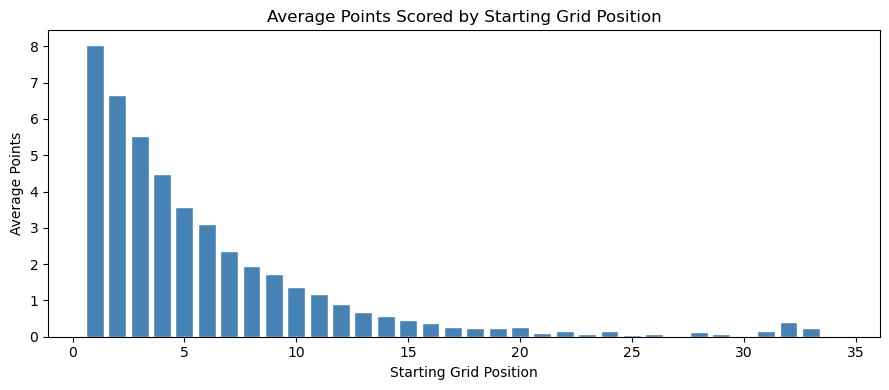

In [12]:
grid_pts = (f1_clean
            .groupby('grid')['points']
            .mean()
            .reset_index())
grid_pts.columns = ['grid', 'avg_points']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(grid_pts['grid'], grid_pts['avg_points'], color='steelblue', edgecolor='white')
ax.set_title('Average Points Scored by Starting Grid Position')
ax.set_xlabel('Starting Grid Position')
ax.set_ylabel('Average Points')
plt.tight_layout()
plt.show()

Even though drivers starting further back gain more positions, they score far fewer points on average. Points drop sharply from grid position 1 onward, and by around position 10 or later the average is close to zero. This tells a more complete story than position gain alone: gaining places from the back is common, but it rarely translates into competitive point-scoring results. Starting position remains one of the strongest predictors of how many points a driver will take home.

### 5.2. Pit Stop Speed and Race Performance

#### Prepare the Analysis Dataset

Pit stop data is not available for every race. We keep only rows where average pit stop time is available. We also rename some columns and convert the necessary variables to numeric variables..

In [13]:
f1_analysis = f1_clean.copy()
# Rename columns if they exist
rename_dict = {}
if "name_x" in f1_analysis.columns:
    rename_dict["name_x"] = "race_name"
if "name_y" in f1_analysis.columns:
    rename_dict["name_y"] = "constructor_name"

f1_analysis = f1_analysis.rename(columns=rename_dict)
f1_analysis = f1_analysis.rename(columns={"positionOrder": "finish_position"})

# Make sure the main numeric columns are numeric
numeric_cols = ["avg_pit_seconds", "positions_gained", "finish_position", "points", "grid", "num_pit_stops"]
for col in numeric_cols:
    f1_analysis[col] = pd.to_numeric(f1_analysis[col], errors="coerce")

f1_pit = f1_analysis[f1_analysis["avg_pit_seconds"].notna()].copy()

f1_pit[[
    "raceId", "year", "driver_name", "constructor_name", "avg_pit_seconds",
    "num_pit_stops", "grid", "finish_position", "positions_gained", "points", "podium"
]].reset_index(drop=True).head()



,raceId,year,driver_name,constructor_name,avg_pit_seconds,num_pit_stops,grid,finish_position,positions_gained,points,podium
0,841,2011,Sebastian Vettel,Red Bull,23.319500,2.0,1,1,0,25.0,True
1,841,2011,Lewis Hamilton,McLaren,23.213000,2.0,2,2,0,18.0,True
2,841,2011,Vitaly Petrov,Renault,25.109000,2.0,6,3,3,15.0,True
3,841,2011,Fernando Alonso,Ferrari,24.055000,3.0,5,4,1,12.0,False
4,841,2011,Mark Webber,Red Bull,24.058667,3.0,3,5,-2,10.0,False


### Main Columns and Descriptive Statistics

The main variables are average pit stop time, number of pit stops, starting grid position, finishing position, positions gained, and points. Positions gained is calculated as starting grid position minus finishing position. Positive values mean the driver improved during the race.

In [14]:
main_columns = [
    "avg_pit_seconds",
    "num_pit_stops",
    "grid",
    "finish_position",
    "positions_gained",
    "points"
]

descriptive_stats = (
    f1_pit[main_columns]
    .describe()
    .T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(2)
)

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
avg_pit_seconds,4502.0,61.44,171.55,16.55,22.13,23.84,27.41,3055.73
num_pit_stops,4502.0,2.05,0.98,1.00,1.00,2.00,3.00,6.00
grid,4502.0,10.96,6.18,1.00,6.00,11.00,16.00,24.00
finish_position,4502.0,10.45,5.89,1.00,5.00,10.00,15.00,24.00
positions_gained,4502.0,0.51,4.96,-23.00,-1.00,1.00,3.00,21.00
points,4502.0,5.19,7.29,0.00,0.00,1.00,10.00,50.00


### Pit Stop Speed vs. Positions Gained
Lower average pit stop time means faster pit stops. If the correlation is negative, that suggests faster pit stops are associated with more positions gained. If the correlation is close to zero, pit stop speed alone may not strongly explain changes in race position.

The plot shows a very dispersed pattern between average pit stop time and positions gained. This suggests that pit stop speed is not a strong predictor of positions gained during a race. The correlation value is close to zero, which also suggests that average pit stop time has little linear relationship with positions gained in this dataset.

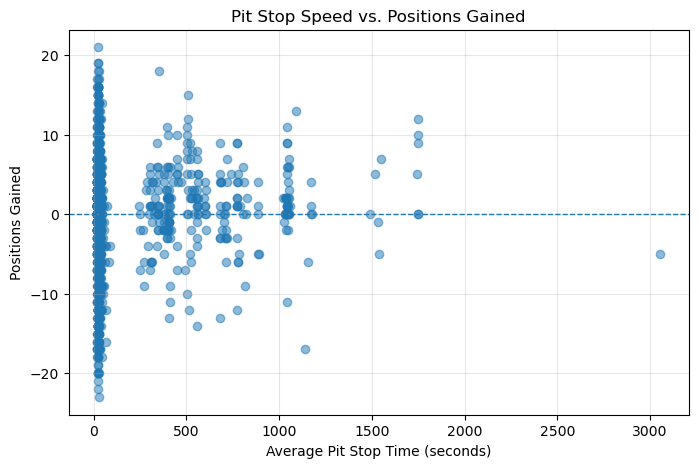

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(f1_pit["avg_pit_seconds"], f1_pit["positions_gained"], alpha=0.5)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Average Pit Stop Time (seconds)")
plt.ylabel("Positions Gained")
plt.title("Pit Stop Speed vs. Positions Gained")
plt.grid(True, alpha=0.3)
plt.show()



In [28]:
pit_position_correlation = f1_pit["avg_pit_seconds"].corr(
    f1_pit["positions_gained"]
)

pd.DataFrame({
    "Relationship": ["Average pit stop time vs. positions gained"],
    "Correlation": [pit_position_correlation]
}).round(3)

,Relationship,Correlation
0,Average pit stop time vs. positions gained,0.031


### Pit Speed Groups

We group average pit stop time into four quartile-based groups: Fastest, Fast, Slow, and Slowest. This allows us to compare race outcomes across different levels of pit stop speed. The pit speed groups show whether faster average pit stops are associated with better race outcomes. If the Fastest group does not gain many more positions than the slower groups, this supports the earlier correlation result that pit stop speed alone is not a strong predictor of position gain.

In [16]:
pit_speed_order = ["Fastest", "Fast", "Slow", "Slowest"]

f1_pit["pit_speed_group"] = pd.qcut(
    f1_pit["avg_pit_seconds"].rank(method="first"),
    q=4,
    labels=pit_speed_order)

f1_pit[["avg_pit_seconds", "pit_speed_group"]].head()

,avg_pit_seconds,pit_speed_group
20776,23.319500,Fast
20777,23.213000,Fast
20778,25.109000,Slow
20779,24.055000,Slow
20780,24.058667,Slow


### Pit speed group summary table

This table compares average pit time, positions gained, finishing position, points, podium rate, and sample size across the four pit speed groups.


In [17]:
def podium_rate(finish_positions):
    return (finish_positions <= 3).mean() * 100

pit_speed_summary = (
    f1_pit.groupby("pit_speed_group", observed=True)
    .agg(
        avg_pit_seconds=("avg_pit_seconds", "mean"),
        avg_positions_gained=("positions_gained", "mean"),
        avg_finish_position=("finish_position", "mean"),
        avg_points=("points", "mean"),
        podium_rate=("finish_position", podium_rate),
        count=("raceId", "count")
    )
    .reset_index()
)

pit_speed_summary = pit_speed_summary.round({
    "avg_pit_seconds": 2,
    "avg_positions_gained": 2,
    "avg_finish_position": 2,
    "avg_points": 2,
    "podium_rate": 2
})

pit_speed_summary

,pit_speed_group,avg_pit_seconds,avg_positions_gained,avg_finish_position,avg_points,podium_rate,count
0,Fastest,20.95,0.54,9.25,6.67,20.07,1126
1,Fast,22.97,0.67,10.40,5.31,16.44,1125
2,Slow,25.05,0.71,11.05,4.38,12.18,1125
3,Slowest,176.70,0.11,11.12,4.41,12.61,1126


### Bar plot: average positions gained by pit speed group

This plot directly compares the average number of positions gained across the four pit speed groups.

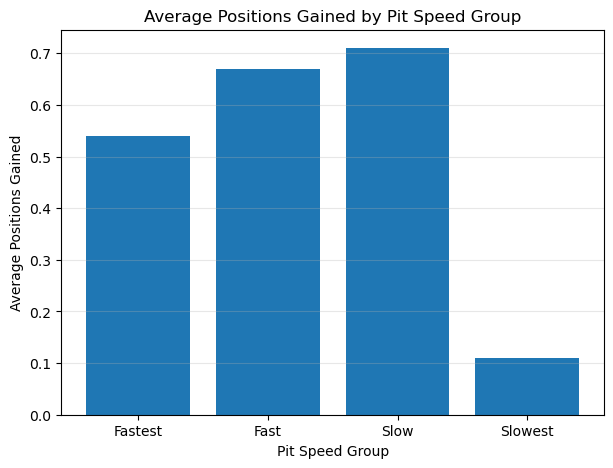

In [18]:
plt.figure(figsize=(7, 5))
plt.bar(
    pit_speed_summary["pit_speed_group"].astype(str),
    pit_speed_summary["avg_positions_gained"]
)
plt.xlabel("Pit Speed Group")
plt.ylabel("Average Positions Gained")
plt.title("Average Positions Gained by Pit Speed Group")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Constructor Performance

Formula One performance also depends on constructor resources, engineering, and race strategy. To avoid over-interpreting constructors with very few observations, we filter the constructor table to include only constructors with at least 50 races in the pit stop analysis dataset.

In [34]:
constructor_summary = (
    f1_pit.groupby("constructor_name")
    .agg(
        avg_positions_gained=("positions_gained", "mean"),
        avg_points=("points", "mean"),
        podium_rate=("finish_position", podium_rate),
        race_count=("raceId", "nunique")
    )
    .reset_index()
)

constructor_summary = constructor_summary[constructor_summary["race_count"] >= 50].copy()

constructor_summary = constructor_summary.round({
    "avg_positions_gained": 2,
    "avg_points": 2,
    "podium_rate": 2
})

top15_constructors = constructor_summary.sort_values(
    "avg_positions_gained",
    ascending=False
).head(15)

top15_constructors


,constructor_name,avg_positions_gained,avg_points,podium_rate,race_count
12,Marussia,2.57,0.02,0.00,54
4,Caterham,2.23,0.00,0.00,55
18,Sauber,1.22,1.08,1.36,158
0,Alfa Romeo,1.08,0.95,0.00,72
10,Lotus F1,0.92,5.31,18.80,74
6,Force India,0.79,3.45,1.69,157
19,Toro Rosso,0.57,1.30,0.61,178
21,Williams,0.53,2.12,3.74,228
13,McLaren,0.24,4.81,9.72,230
17,Renault,0.16,2.46,2.31,119


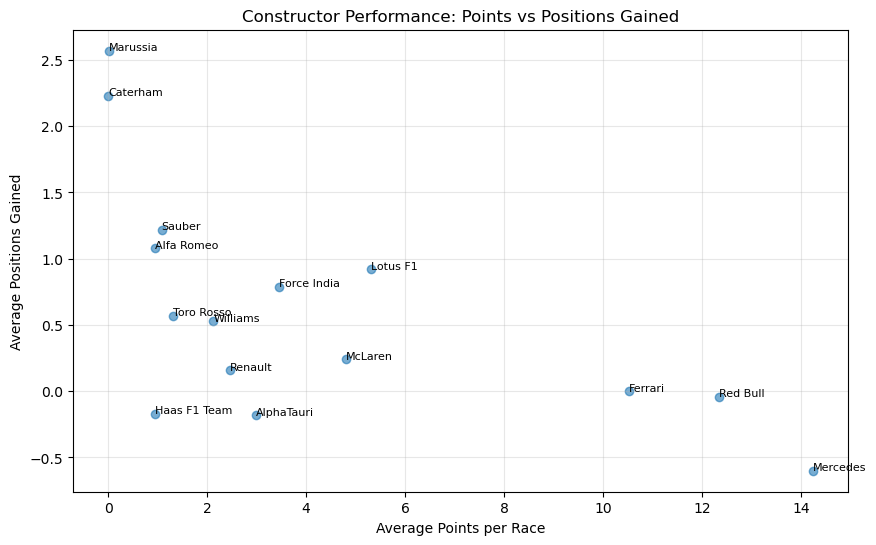

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(
    constructor_summary["avg_points"], 
    constructor_summary["avg_positions_gained"],
    alpha=0.6
)
plt.xlabel("Average Points per Race")
plt.ylabel("Average Positions Gained")
plt.title("Constructor Performance: Points vs Positions Gained")
for i, row in constructor_summary.iterrows():
    plt.annotate(row["constructor_name"], (row["avg_points"], row["avg_positions_gained"]), fontsize=8)
plt.grid(alpha=0.3)
plt.show()

### Year Trend

This section examines whether average positions gained changed over time in the subset of races with pit stop data.

In [21]:
year_trend = (
    f1_pit.groupby("year")
    .agg(
        avg_positions_gained=("positions_gained", "mean"),
        avg_pit_seconds=("avg_pit_seconds", "mean"),
        race_records=("raceId", "count")
    )
    .reset_index()
)

year_trend.round(2).head()

,year,avg_positions_gained,avg_pit_seconds,race_records
0,2011,0.46,24.77,429
1,2012,0.73,23.20,447
2,2013,0.33,24.35,401
3,2014,0.45,45.64,378
4,2015,0.47,25.82,346


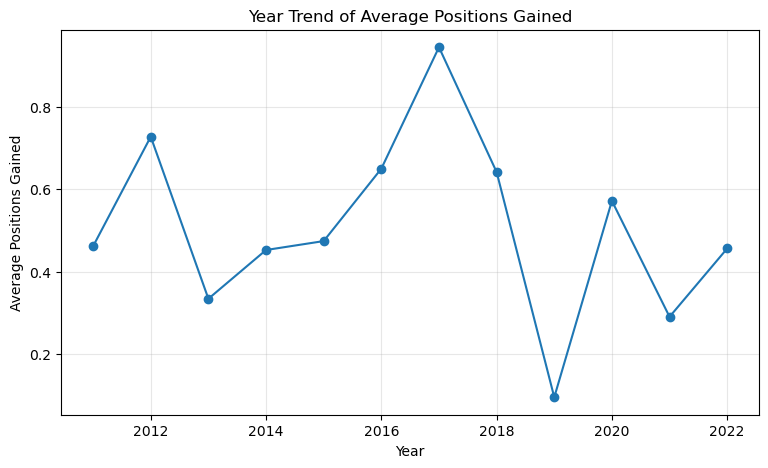

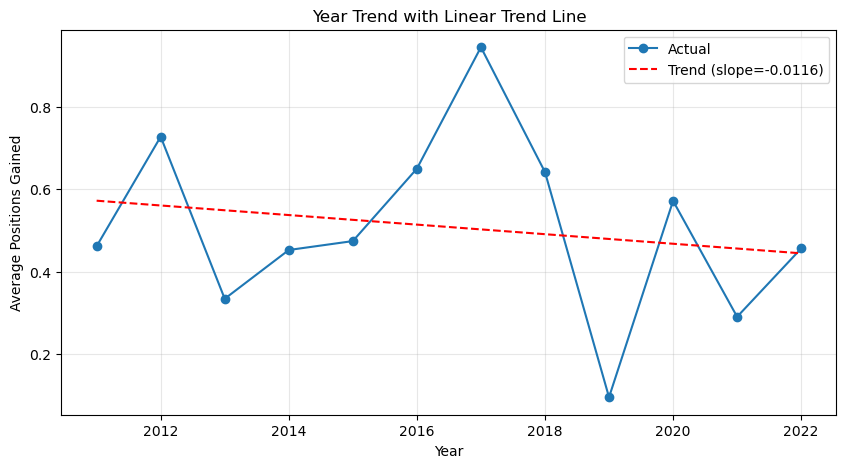

Trend slope: -0.0116 positions/year


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    year_trend["year"],
    year_trend["avg_positions_gained"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Average Positions Gained")
plt.title("Year Trend of Average Positions Gained")
plt.grid(True, alpha=0.3)
plt.show()


## 6. Discussion

Overall, our analysis shows that starting grid position is one of the strongest factors related to Formula One race performance. Drivers who start near the front tend to score more points on average, which suggests that qualifying and starting position give drivers an important advantage before the race even begins. Although drivers starting farther back may sometimes gain more positions, they usually still finish with fewer points. This means that positions gained is useful for measuring improvement during a race, but it does not fully represent overall race success.

Our results also show that pit stop speed has a weaker relationship with positions gained than we expected. The scatter plot and correlation suggest that average pit stop time alone does not strongly predict how many positions a driver gains. However, constructor performance still appears to matter because teams differ in car quality, engineering, pit strategy, and overall race execution. One limitation of our analysis is that pit stop data is not available for every race in Formula One history, so the pit stop results only represent the races where this data exists. In conclusion, race performance is influenced by multiple factors, but starting grid position and constructor strength seem more directly connected to better results than pit stop speed alone.